In [18]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.linear_model import LinearRegression

# 🔹 STEP 1: Load Datasets
companies = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-companies.csv", encoding='latin1', low_memory=False)
funding_rounds = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-rounds.csv", encoding='latin1', low_memory=False)
investments = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-investments.csv", encoding='latin1', low_memory=False)
acquisitions = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-acquisitions.csv", encoding='latin1', low_memory=False)

# 🔹 STEP 2: Filter & Rename Columns for Consistency
companies = companies[companies['founded_year'] <= 2013]  # Keep only companies founded before 2013
companies.rename(columns={'permalink': 'company_permalink'}, inplace=True)

# 🔹 Handle Missing Values - Founded Year (Regression Imputation)
companies['permalink_length'] = companies['company_permalink'].str.len()  # Feature for regression
train_data = companies.dropna(subset=['founded_year'])
test_data = companies[companies['founded_year'].isnull()]

X_train = train_data[['permalink_length']]
y_train = train_data['founded_year']
X_test = test_data[['permalink_length']]

reg = LinearRegression()
reg.fit(X_train, y_train)
companies.loc[companies['founded_year'].isnull(), 'founded_year'] = reg.predict(X_test)

# 🔹 Handle Missing Values - Funding (Linear Interpolation)
companies['funding_total_usd'] = companies['funding_total_usd'].interpolate(method='linear')

# 🔹 Handle Categorical Missing Values (Mode Imputation)
companies['category_code'] = companies['category_code'].fillna(companies['category_code'].mode()[0])

# 🔹 Convert Founded Year to Company Age
companies['company_age'] = 2013 - companies['founded_year']

# 🔹 Drop Unnecessary Columns
companies.drop(['founded_at', 'closed_at', 'category_code'], axis=1, inplace=True, errors='ignore')

# 🔹 STEP 3: Aggregate Funding Data
funding_rounds['raised_amount_usd'] = funding_rounds['raised_amount_usd'].fillna(0)
funding_agg = funding_rounds.groupby('company_permalink')['raised_amount_usd'].sum().reset_index()
funding_agg.rename(columns={'raised_amount_usd': 'total_funding_received'}, inplace=True)

# 🔹 STEP 4: Aggregate Investment Data
investor_count = investments.groupby('company_permalink')['investor_permalink'].nunique().reset_index()
investor_count.rename(columns={'investor_permalink': 'num_investors'}, inplace=True)

# 🔹 STEP 5: Label Acquisitions
acquisitions['acquired'] = 1
acquisitions = acquisitions[['company_permalink', 'acquired']]

# 🔹 STEP 6: Merge Processed Data
final_df = companies.merge(funding_agg, on='company_permalink', how='left')
final_df = final_df.merge(investor_count, on='company_permalink', how='left')
final_df = final_df.merge(acquisitions, on='company_permalink', how='left')

# 🔹 Fill Remaining Missing Values (KNN Imputer)
knn_imputer = KNNImputer(n_neighbors=5)
final_df[['total_funding_received', 'num_investors']] = knn_imputer.fit_transform(final_df[['total_funding_received', 'num_investors']])

# 🔹 STEP 7: Remove Outliers Using IQR
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[column] >= (Q1 - 1.5 * IQR)) & (df[column] <= (Q3 + 1.5 * IQR))]

final_df = remove_outliers(final_df, 'total_funding_received')
final_df = remove_outliers(final_df, 'num_investors')

# 🔹 STEP 8: Standardization (Z-score Scaling)
scaler = StandardScaler()
final_df[['total_funding_received', 'num_investors', 'company_age']] = scaler.fit_transform(
    final_df[['total_funding_received', 'num_investors', 'company_age']]
)

# 🔹 STEP 9: Normalization (Min-Max Scaling)
minmax_scaler = MinMaxScaler()
final_df[['total_funding_received', 'num_investors', 'company_age']] = minmax_scaler.fit_transform(
    final_df[['total_funding_received', 'num_investors', 'company_age']]
)

# 🔹 STEP 10: Save Final Processed Dataset
final_df.to_csv("/Users/macbook/Downloads/preprocessed_startup_data_2013_advanced.csv", index=False)
print("✅ Preprocessing complete! Data saved as 'preprocessed_startup_data_2013_advanced.csv'.")


/var/folders/lk/r885r3ys0cvgst4w96lxp06m0000gn/T/ipykernel_1445/2883436319.py:33: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  companies['funding_total_usd'] = companies['funding_total_usd'].interpolate(method='linear')


✅ Preprocessing complete! Data saved as 'preprocessed_startup_data_2013_advanced.csv'.


In [6]:
import pandas as pd
import numpy as np

# Load the data
df = pd.read_csv('/Users/macbook/Downloads/preprocessed_startup_data_2008_v2.csv')

# Calculate z-scores
mean = df['funding_total_usd'].mean()
std = df['funding_total_usd'].std()
z_scores = (df['funding_total_usd'] - mean) / std

# Set threshold
threshold = 3  # Change to 2 for more conservative filtering

# Filter out outliers
df_filtered = df[(np.abs(z_scores) < threshold)]

# Save the filtered file
df_filtered.to_csv('/Users/macbook/Downloads/preprocessed_startup_data_2008_v6.csv', index=False)

print(f"Original rows: {len(df)}, Filtered rows: {len(df_filtered)}")


Original rows: 1111, Filtered rows: 999


In [36]:
import pandas as pd

# 🔹 Load Processed and Rounds Datasets
processed_df = pd.read_csv("/Users/macbook/Downloads/processed_startup_data_with_target_encoding6.csv")
rounds_df = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-rounds.csv", encoding='latin1', low_memory=False)

# 🔹 Keep Only Needed Columns (renamed to funding_round_type)
rounds_df = rounds_df[['company_permalink', 'funding_round_type']]
rounds_df['funding_round_type'] = rounds_df['funding_round_type'].fillna('unknown')

# 🔹 One-Hot Encode Funding Round Types
one_hot_rounds = pd.get_dummies(rounds_df['funding_round_type'])
rounds_encoded = pd.concat([rounds_df['company_permalink'], one_hot_rounds], axis=1)

# 🔹 Aggregate (Group by Company)
rounds_encoded = rounds_encoded.groupby('company_permalink').sum().reset_index()

# 🔹 Merge with Processed Dataset
merged_df = processed_df.merge(rounds_encoded, on='company_permalink', how='left')
merged_df.fillna(0, inplace=True)  # Fill missing one-hot entries with 0s

# 🔹 Save Updated Dataset
merged_df.to_csv("/Users/macbook/Downloads/preprocessed_startup_data_2008_v8.csv", index=False)
print("✅ One-hot encoded funding round types added. Saved as 'preprocessed_startup_data_2008_v8.csv'.")


✅ One-hot encoded funding round types added. Saved as 'preprocessed_startup_data_2008_v8.csv'.


In [38]:
import pandas as pd

# 🔹 Load Processed and Rounds Datasets
processed_df = pd.read_csv("/Users/macbook/Downloads/processed_startup_data_with_target_encoding6.csv")
rounds_df = pd.read_csv("/Users/macbook/Downloads/archive/crunchbase-rounds.csv", encoding='latin1', low_memory=False)

# 🔹 Keep Only Needed Columns
rounds_df = rounds_df[['company_permalink', 'funding_round_type']]
rounds_df['funding_round_type'] = rounds_df['funding_round_type'].fillna('unknown')

# 🔹 Select Most Frequent Funding Round Type Per Company
# (i.e., the mode of the funding_round_type per company)
most_common_rounds = rounds_df.groupby('company_permalink')['funding_round_type'] \
                              .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'unknown') \
                              .reset_index()

# 🔹 Merge with Processed Dataset
merged_df = processed_df.merge(most_common_rounds, on='company_permalink', how='left')
merged_df['funding_round_type'] = merged_df['funding_round_type'].fillna('unknown')

# 🔹 Save Updated Dataset
merged_df.to_csv("/Users/macbook/Downloads/preprocessed_startup_data_2008_v9.csv", index=False)
print("✅ Most frequent funding_round_type added. Saved as 'preprocessed_startup_data_2008_v8.csv'.")


✅ Most frequent funding_round_type added. Saved as 'preprocessed_startup_data_2008_v8.csv'.


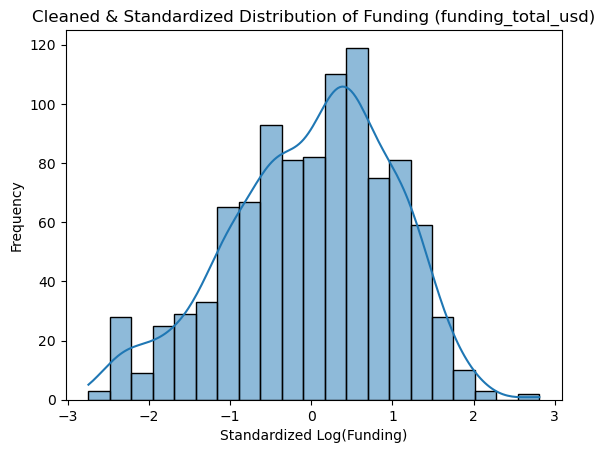

✅ Preprocessing complete! Data saved as 'preprocessed_startup_data_2013_advanced.csv'.
Skew: nan
Kurtosis: nan


In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Load the data
df = pd.read_csv('/Users/macbook/Downloads/preprocessed_startup_data_v10.csv')

# Step 1: Log-transform 'funding_total_usd'
raised_log = np.log1p(df['funding_total_usd'])

# Step 2: IQR-based outlier capping
Q1 = raised_log.quantile(0.25)
Q3 = raised_log.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
raised_capped = raised_log.clip(lower, upper)

# Step 3: Standardize the cleaned values
scaler = StandardScaler()
df['funding_total_usd'] = scaler.fit_transform(raised_capped.values.reshape(-1, 1))

# Step 4: Plot the cleaned data
sns.histplot(df['funding_total_usd'], kde=True)
plt.title("Cleaned & Standardized Distribution of Funding (funding_total_usd)")
plt.xlabel("Standardized Log(Funding)")
plt.ylabel("Frequency")
plt.show()

# Step 5: Save the final processed dataset
df.to_csv("/Users/macbook/Downloads/preprocessed_startup_data_2013_advanced.csv", index=False)
print("✅ Preprocessing complete! Data saved as 'preprocessed_startup_data_2013_advanced.csv'.")
from scipy.stats import skew, kurtosis
print("Skew:", skew(df['funding_total_usd']))
print("Kurtosis:", kurtosis(df['funding_total_usd']))


In [23]:
import pandas as pd

# Load the dataset
df = pd.read_csv("/Users/macbook/Downloads/preprocessed_startup_data_2008_v9.csv")  # Replace with your actual file path

# One-hot encode the 'funding_round_type' column
df_encoded = pd.get_dummies(df, columns=['funding_round_type'], prefix='round', drop_first=False)

# Save the updated DataFrame
df_encoded.to_csv("onehot_funding_round_type.csv", index=False)

print("✅ One-hot encoding complete. Encoded file saved as 'onehot_funding_round_type.csv'")

✅ One-hot encoding complete. Encoded file saved as 'onehot_funding_round_type.csv'


In [27]:
import pandas as pd
from category_encoders import TargetEncoder

# Load your dataset
df = pd.read_csv("/Users/macbook/Downloads/preprocessed_startup_data_v10.csv")  # Replace with your file path

# Assume you already have a binary target column
# target = 1 for IPO/acquired, 0 for operating/closed
df['target'] = df['acquired']  # Or create it based on your logic

# Clean the column to be encoded (example: 'state_code')
df['state_code'] = df['state_code'].astype(str).str.strip().str.upper()

# Optional: Group rare states with few samples into "Other"
state_counts = df['state_code'].value_counts()
rare_states = state_counts[state_counts < 10].index
df['state_code_grouped'] = df['state_code'].apply(lambda x: 'Other' if x in rare_states else x)

# Apply regularized target encoding
encoder = TargetEncoder(cols=['state_code_grouped'], smoothing=5)
df['state_code_encoded'] = encoder.fit_transform(df['state_code_grouped'], df['target'])

# Save the updated DataFrame
df.to_csv("processed_with_state_target_encoding.csv", index=False)

print("✅ Target encoding complete. Encoded file saved as 'processed_with_state_target_encoding.csv'")

ModuleNotFoundError: No module named 'category_encoders'